# Handwritten Digit Classification using CNN

This project focuses on building a robust handwritten digit recognition system using a Convolutional Neural Network (CNN). The model is trained on grayscale digit images to accurately classify numbers from 0–9

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import datasets, layers, models
from keras.utils import to_categorical,plot_model
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D ,BatchNormalization,Dense,Flatten,Dropout,Input
from IPython.display import display,Image
import tempfile
from sklearn.model_selection import train_test_split
import cv2
from keras.optimizers import SGD

### Load the dataset

Loading the the MNIST dataset into training and testing sets, providing images (x_train, x_test) and their corresponding labels (y_train, y_test).

In [2]:
(x_train,y_train),(x_test,y_test) = datasets.mnist.load_data()

In [3]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


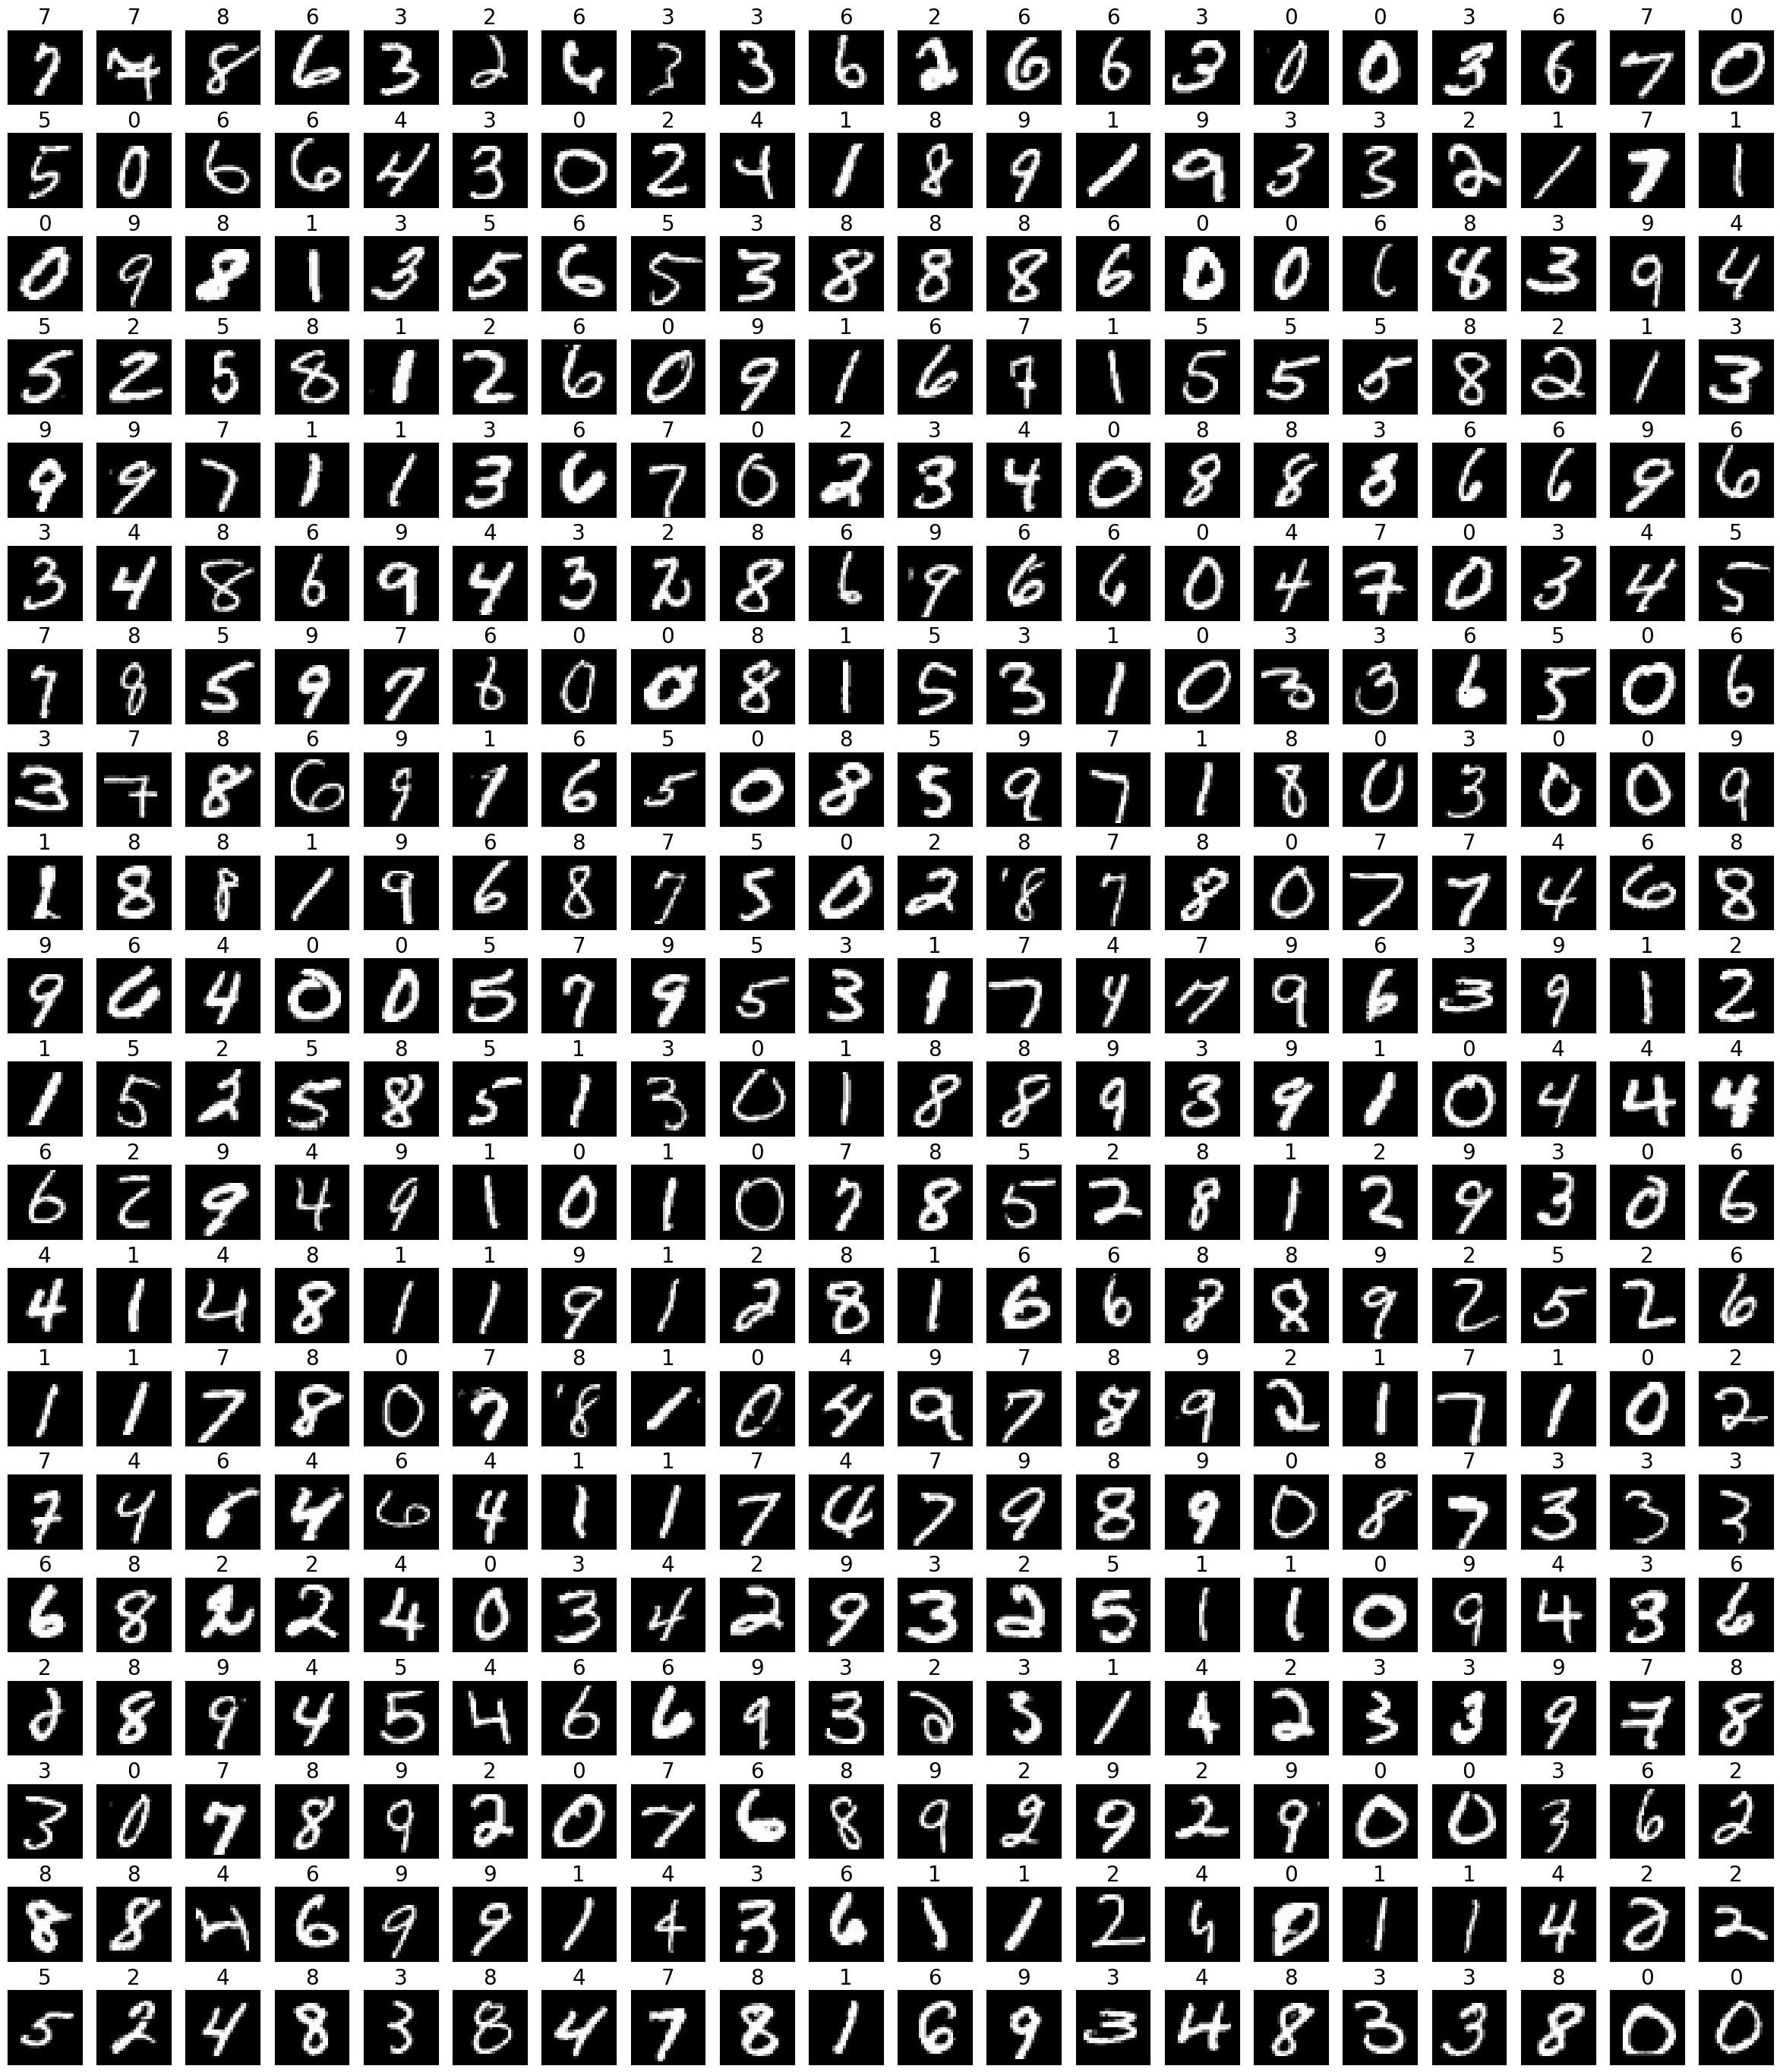

In [4]:
'''
A sample of 400 images from the training dataset is displayed in a grid format to visualize the variation and patterns in handwritten digits
'''

_array = np.random.randint(low=1,high=10000,size=400)
_fig = plt.figure(figsize=(30,35))

for i in range(400):
    _fig.add_subplot(20,20,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.title(y_train[_array[i]],fontsize=20)
    plt.imshow(x_train[_array[i]],cmap='gray')

##### Converting the labels to one hot encoded labels

In [5]:
'''
The labels are transformed into one-hot encoded vectors where each class is represented as a binary array
e.g digit 5 is encoded as [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
'''
y_train_enc = to_categorical(y_train)
y_test_enc = to_categorical(y_test)

##### Preprocessing the images

In [6]:
'''
The image pixel values are scaled to the range [0, 1] by dividing by 255, which improves training efficiency and helps the model converge faster.
'''
x_train_norm = x_train/255.0
x_test_norm = x_test/255.0

In [7]:
x_train_norm = x_train_norm.reshape((x_train_norm.shape[0],28,28,1))
x_test_norm = x_test_norm.reshape((x_test_norm.shape[0],28,28,1))

##### Model Architecture

In [8]:
_model = Sequential(
    [
        Input(shape=(28, 28, 1)),
        Conv2D(32,(3,3),activation='relu'),
        MaxPooling2D(2,2),
        Dropout(0.25),
        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),
        Dropout(0.25),
        Flatten(),
        Dense(100,activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(10,activation='softmax')
    ]
)

_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │         160,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 100)                 │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 180,326 (704.40 KB)

 Trainable params: 180,126 (703.62 KB)

 Non-trainable params: 200 (800.00 B)

In [9]:
_model.compile(loss='categorical_crossentropy',optimizer=SGD(momentum=0.9),metrics=['accuracy'])

### splitting for validation and testing sets

In [10]:
#The pixel values of the images are normalized to the range [0, 1] by dividing by 255. This helps in faster convergence during training.

x_val,x_test,y_val,y_test = train_test_split(x_test_norm,y_test_enc,test_size=0.5)

print(x_train_norm.shape)
print(x_test_norm.shape)
print(x_val.shape)
print(y_val.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)
(5000, 28, 28, 1)
(5000, 10)
(5000, 28, 28, 1)
(5000, 10)


### Model training

In [11]:
_mod_train = _model.fit(x=x_train_norm,y=y_train_enc,batch_size=64,validation_data=(x_val,y_val),epochs=15)

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 30ms/step - accuracy: 0.9205 - loss: 0.2607 - val_accuracy: 0.9786 - val_loss: 0.0626
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.9637 - loss: 0.1199 - val_accuracy: 0.9820 - val_loss: 0.0544
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.9710 - loss: 0.0962 - val_accuracy: 0.9854 - val_loss: 0.0440
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9750 - loss: 0.0858 - val_accuracy: 0.9884 - val_loss: 0.0347
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9770 - loss: 0.0742 - val_accuracy: 0.9892 - val_loss: 0.0295
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.9801 - loss: 0.0676 - val_accuracy: 0.9880 - val_loss: 0.0334
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.9804 - loss: 0.0638 - val_accuracy: 0.9912 - val_loss: 0.0254
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.9812 - loss: 0.0591 - 

### Model Evaluation

Both cross-entropy loss and classification accuracy improved consistently, with validation performance remaining strong throughout training. Since the validation loss stayed low and did not diverge from the training loss, the model does not show strong signs of overfitting and appears to generalize well to unseen handwritten digit images.

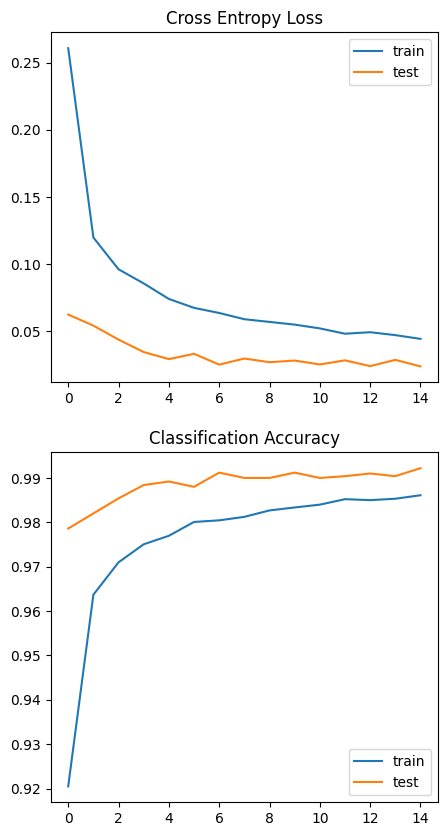

In [12]:
_val_loss = _mod_train.history['val_loss']
_val_accuracy = _mod_train.history['val_accuracy']
_loss = _mod_train.history['loss']
_accuracy = _mod_train.history['accuracy']

fig = plt.figure(figsize=(5, 10))
fig.add_subplot(2, 1, 1)
plt.title('Cross Entropy Loss')
plt.plot(_loss, label='train')
plt.plot(_val_loss, label='test')
plt.legend()

fig.add_subplot(2, 1, 2)
plt.title('Classification Accuracy')
plt.plot(_accuracy, label='train')
plt.plot(_val_accuracy, label='test')
plt.legend()

In [13]:
metrics = _model.evaluate(x_test, y_test)
print("Test Accuracy is : {:.2f}".format(metrics[1] * 100))
print("Test Loss is : {:.2f}".format(metrics[0]))


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9946 - loss: 0.0216
Test Accuracy is : 99.46
Test Loss is : 0.02


In [14]:
_model.save('digitclassification.keras')

### Prediction on Testing data

In [15]:
loaded_model = tf.keras.models.load_model('digitclassification.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


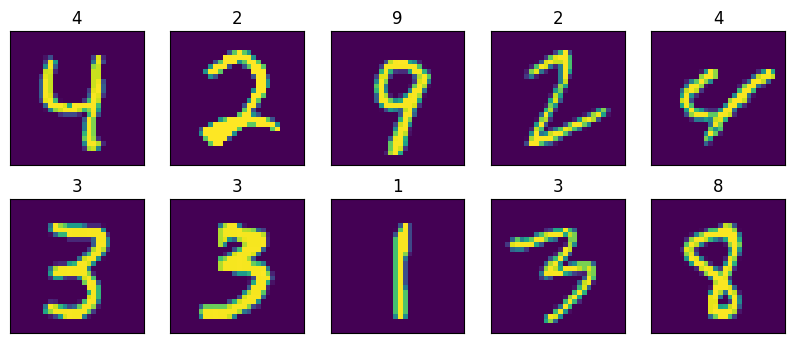

In [16]:
index = np.random.randint(low=0,high=5000,size=10)
fig = plt.figure(figsize=(10,4))
for i in range(10):
    pred = np.argmax(loaded_model.predict(x_test[index[i]].reshape(1,28,28,1)))
    fig.add_subplot(2,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.title(pred)
    plt.imshow(x_test[index[i]].reshape(28,28))


### prediction on custom images

The image is read and preprocessed by removing noise and converting it to a binary format. Contours are then detected to identify individual digits, which are filtered and sorted in the correct order. Each digit is extracted, centered, resized, and normalized before being passed into a trained CNN model for prediction, and the final recognized numbers are displayed.

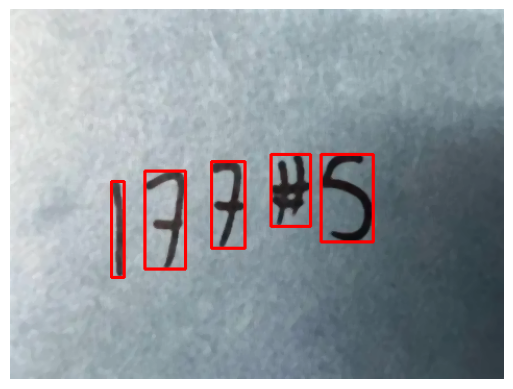

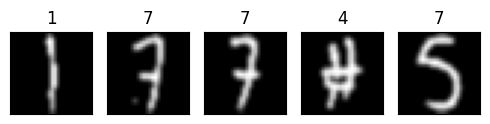

The Recognized Numbers are: 1 7 7 4 7


In [17]:
def recognize_number(filepath):
    image = cv2.imread(filepath)
    image = cv2.medianBlur(image, 5)
    grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    thresh = cv2.adaptiveThreshold(
        grey, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31, 10
    )

    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    kernel_vertical = np.ones((3,1), np.uint8)
    kernel_horizontal = np.ones((1,3), np.uint8)
    
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel_vertical)

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    filtered = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        area = cv2.contourArea(c)

        if area > 80 and 10 < w < 100 and 15 < h < 120:
            filtered.append(c)

    boundingBoxes = [cv2.boundingRect(c) for c in filtered]
    sorted_pairs = sorted(zip(filtered, boundingBoxes), key=lambda b: b[1][1])

    rows = []
    current_row = []
    row_threshold = 40

    for cnt, box in sorted_pairs:
        x, y, w, h = box

        if not current_row:
            current_row.append((cnt, box))
            continue

        _, prev_box = current_row[-1]

        if abs(y - prev_box[1]) < row_threshold:
            current_row.append((cnt, box))
        else:
            rows.append(current_row)
            current_row = [(cnt, box)]
    if current_row:
        rows.append(current_row)

    final = []
    for row in rows:
        row_sorted = sorted(row, key=lambda b: b[1][0])
        final.extend(row_sorted)
    contours, boundingBoxes = zip(*final)
    preprocessed_digits = []

    for c in contours:
        x, y, w, h = cv2.boundingRect(c)

        cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)
        digit = thresh[y:y+h, x:x+w]
        size = max(w, h) + 10
        square = np.zeros((size, size), dtype=np.uint8)
        x_offset = (size - w) // 2
        y_offset = (size - h) // 2
        square[y_offset:y_offset+h, x_offset:x_offset+w] = digit
        resized = cv2.resize(square, (28, 28))
        resized = cv2.GaussianBlur(resized, (3, 3), 0)
        processed = resized / 255.0
        preprocessed_digits.append(processed)

    plt.imshow(image)
    plt.axis('off')
    plt.show()

    nums = []
    fig = plt.figure(figsize=(len(preprocessed_digits), 4))

    for i, digit in enumerate(preprocessed_digits):
        pred = np.argmax(
            loaded_model.predict(
                digit.reshape(1, 28, 28, 1),
                verbose=0
            )
        )

        nums.append(pred)

        fig.add_subplot(1, len(preprocessed_digits), i + 1)
        plt.imshow(digit.reshape(28, 28), cmap="gray")
        plt.title(pred)
        plt.xticks([])
        plt.yticks([])

    plt.tight_layout()
    plt.show()

    print("The Recognized Numbers are:", *nums)

recognize_number('./custom_images/1.png')

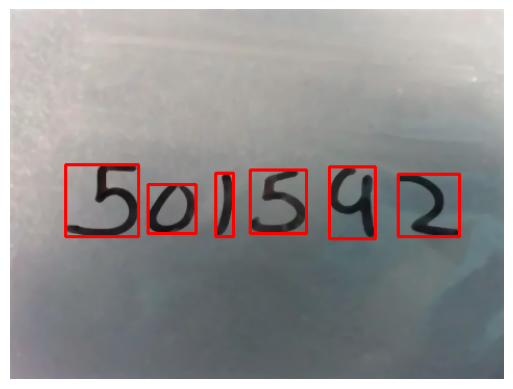

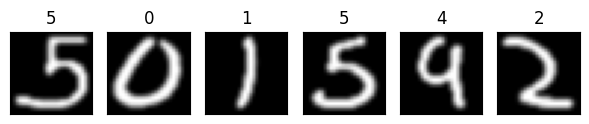

The Recognized Numbers are: 5 0 1 5 4 2


In [18]:
recognize_number('./custom_images/2.png')

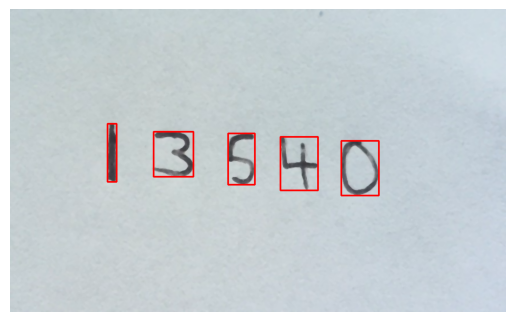

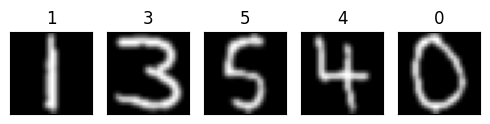

The Recognized Numbers are: 1 3 5 4 0


In [19]:
recognize_number('./custom_images/3.png')

# Conclusion

A Convolutional Neural Network(CNN) was built that can effectively classify handwritten digits after standard preprocessing, normalization, and reshaping of the MNIST dataset. The model learned meaningful visual patterns from the training data and showed strong performance on validation and test samples, confirming that CNNs are well suited for image-based digit recognition tasks.

The model was also applied to custom handwritten images using OpenCV-based preprocessing, contour detection, digit extraction, and resizing before prediction. This showed that the system can go beyond the MNIST test set and work on real handwritten inputs, although prediction quality still depends on image clarity, segmentation accuracy, and how closely the handwritten digits resemble the training data.

For the custom images, the saved notebook outputs show these predicted sequences:

Image 1: 17745
Image 2: 501542
Image 3: 13540

The model predicted the custom handwritten sequences as 17745, 501542, and 13540. In the first image, the symbol that visually resembles # was interpreted by the CNN as the digit 4, showing that the model maps unfamiliar handwritten shapes to the closest learned digit pattern.